In [152]:
import pickle
import scipy.signal
from scipy import signal
import h5py
import numpy as np


In [153]:
def load_ssvep_data(file_path):
    """
    Load EEG-Data and Trigger from .mat v7.3 (HDF5)
    
    As I tried it with loadmat from scipy.io I had the following error
    "NotImplementedError: Please use HDF reader for matlab v7.3 files, e.g. h5py"
    Thats why I use h5py
    """
    with h5py.File(file_path, "r") as f:
       # print(list(f.keys())) # check keys name - its "y" thats why I use y below
       # print(f["y"].shape)
        raw_data = f["y"][:]    # get the real np.ndarray from the data          
        eegs     = raw_data[:, 1:9]       # CH2 bis CH9 → EEG
        triggers = raw_data[:, 9]         # CH10 → Trigger (LED on/off)

    return eegs, triggers

# load data
eeg_data, trigger_data = load_ssvep_data("ssvep/subject_1_fvep_led_training_1.mat")
#print(trigger_data)

print("EEG shape:", eeg_data.shape)
print("Trigger shape:", trigger_data.shape)
# mne - maybe transponse to (n_channels, n_samples) - for ICA, CSP etc

EEG shape: (57728, 8)
Trigger shape: (57728,)


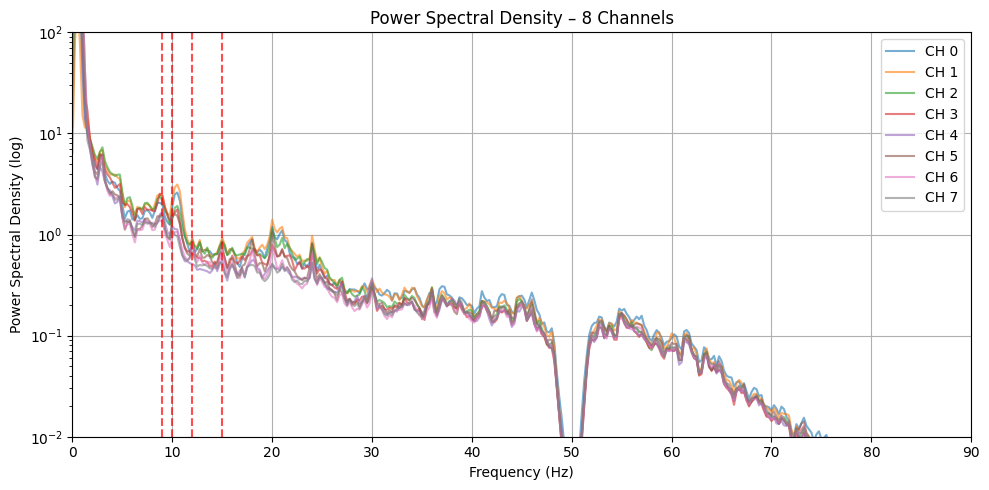

In [154]:
# Power Spectral Density (PSD) Analysis

import matplotlib.pyplot as plt
from scipy.signal import welch

plt.figure(figsize=(10, 5))


for ch in range(eeg_data.shape[1]):
    freqs, psd = welch(eeg_data[:, ch], fs=256, nperseg=1024)
    plt.semilogy(freqs, psd, label=f"CH {ch}", alpha=0.6)
# *** but why nperseg=1024? 
# SO we want to separate 9Hz from 10Hz 
# delta f = sampling_rate / points_count
# points_count = 256 (sampling rate) * 4 (seconds) = 1024
# then delta f = 256 / 1024 = 0.25 
# - meaning we cannot distinguish between 10Hz and 10.25Hz anymore
# but thats ok as we want to separate 9Hz from 10Hz (1 Hz difference < 0.25)

# SSVEP-Frequencies
for target_freq in [9, 10, 12, 15]:
    plt.axvline(x=target_freq, color='red', linestyle='--', alpha=0.7)

plt.xlim(0, 90)  # x - Frequency
plt.ylim(1e-2, 1e2)  # y - Power 
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (log)")
plt.title("Power Spectral Density – 8 Channels")
plt.grid(True)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


# Notch Filter at 50Hz already applied
# Peak at 20 Hz - 2. harmonics for 10Hz or artefact? muscel activity?

In [ ]:
# Just to know the duration of data
sfreq = 256.0 #sampling rate
duration_seconds = len(eeg_data) / 256
print("Duration in seconds:", duration_seconds)
print("...in minutes:", duration_seconds / 60)


Duration in seconds: 225.5
...in minutes: 3.7583333333333333


In [155]:
# we want to work with data in MNE compatible format, so..
import mne

eeg_data = eeg_data.T # transpose for MNE

# Channels from Montagepicture
ch_names = ["PO7", "PO3", "POz", "PO4", "PO8", "O1", "Oz", "O2"]
ch_types = ["eeg"] * 8

# Info-Objekt for MNE
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

# RawArray 
# with raw.get_data() - (n_channels, n_samples)
raw = mne.io.RawArray(eeg_data, info) #so it is MNE compatible

# Montage:
# I suppose the name from https://mne.tools/stable/auto_tutorials/intro/40_sensor_locations.html
raw.set_montage("standard_1020")



Creating RawArray with float64 data, n_channels=8, n_times=57728
    Range : 0 ... 57727 =      0.000 ...   225.496 secs
Ready.


<RawArray | 8 x 57728 (225.5 s), ~3.5 MiB, data loaded>

In [156]:
'''BrokenPipeError# Plot the muscle artefacts with annotate_muscle_zscore()

# Why threshold = 4 ? Just took it from https://mne.tools/stable/generated/mne.preprocessing.annotate_muscle_zscore.html
annotations, scores = mne.preprocessing.annotate_muscle_zscore(
    raw, ch_type="eeg", threshold=4.0,  filter_freq=(110, 127)
)
raw.set_annotations(annotations)
raw.plot()'''

'BrokenPipeError# Plot the muscle artefacts with annotate_muscle_zscore()\n\n# Why threshold = 4 ? Just took it from https://mne.tools/stable/generated/mne.preprocessing.annotate_muscle_zscore.html\nannotations, scores = mne.preprocessing.annotate_muscle_zscore(\n    raw, ch_type="eeg", threshold=4.0,  filter_freq=(110, 127)\n)\nraw.set_annotations(annotations)\nraw.plot()'

In [157]:
'''# SO WHERE ARE THE MUSCLE ARTEFACTS?
# more about: https://mne.tools/stable/generated/mne.Annotations.html
print(raw.annotations)
print(raw.annotations.onset)       # starttime in sec
print(raw.annotations.duration)    # duration in seconds

# so we have muscle artefact at the beginning ---> cut it out
'''

'# SO WHERE ARE THE MUSCLE ARTEFACTS?\n# more about: https://mne.tools/stable/generated/mne.Annotations.html\nprint(raw.annotations)\nprint(raw.annotations.onset)       # starttime in sec\nprint(raw.annotations.duration)    # duration in seconds\n\n# so we have muscle artefact at the beginning ---> cut it out\n'

In [60]:
# Check the raw Object with all the Data
print("Samplingrate:", raw.info['sfreq'], "Hz")
print("Channels:", raw.ch_names)
print("Channel types:", raw.get_channel_types())
print("Form:", raw.get_data().shape)
print("Duration:", raw.times[-1], "seconds")
print("Montage:", raw.get_montage())
raw.info


Samplingrate: 256.0 Hz
Channels: ['PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2']
Channel types: ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']
Form: (8, 57728)
Duration: 225.49609375 seconds
Montage: <DigMontage | 0 extras (headshape), 0 HPIs, 3 fiducials, 8 channels>


<Info | 8 non-empty values
 bads: []
 ch_names: PO7, PO3, POz, PO4, PO8, O1, Oz, O2
 chs: 8 EEG
 custom_ref_applied: False
 dig: 11 items (3 Cardinal, 8 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 8
 projs: []
 sfreq: 256.0 Hz
>

In [ ]:
# bandpass filter
raw_filtered = raw.copy().filter(l_freq=6.0, h_freq=30.0)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 6 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 6.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 423 samples (1.652 s)



Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 5 components
Fitting ICA took 0.1s.


/var/folders/b_/13ns3vn128sfcpkm5ql4glyw0000gn/T/ipykernel_19446/3988334144.py:2: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


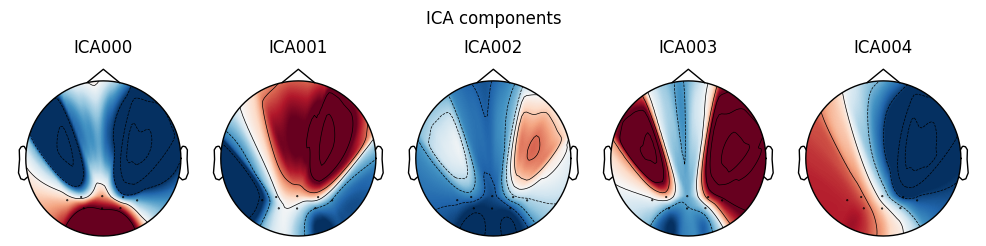

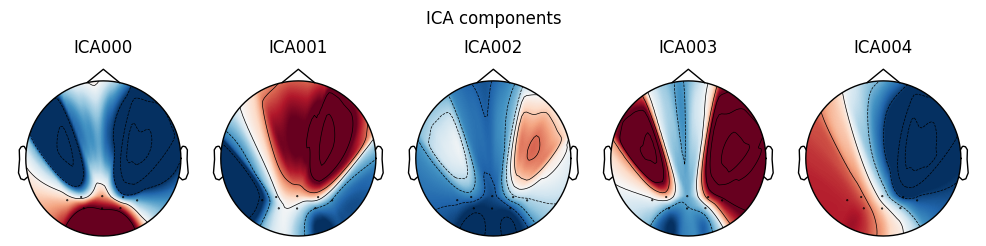

In [158]:
ica = mne.preprocessing.ICA(n_components=5, random_state=97)
ica.fit(raw)
ica.plot_components()
#ica.exclude = [index_of_muscle_component]
#raw_corrected = raw.copy()
#ica.apply(raw_corrected)

Creating RawArray with float64 data, n_channels=5, n_times=57728
    Range : 0 ... 57727 =      0.000 ...   225.496 secs
Ready.
Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/b_/13ns3vn128sfcpkm5ql4glyw0000gn/T/ipykernel_19446/1892316288.py:9: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot(picks='ICA000')
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


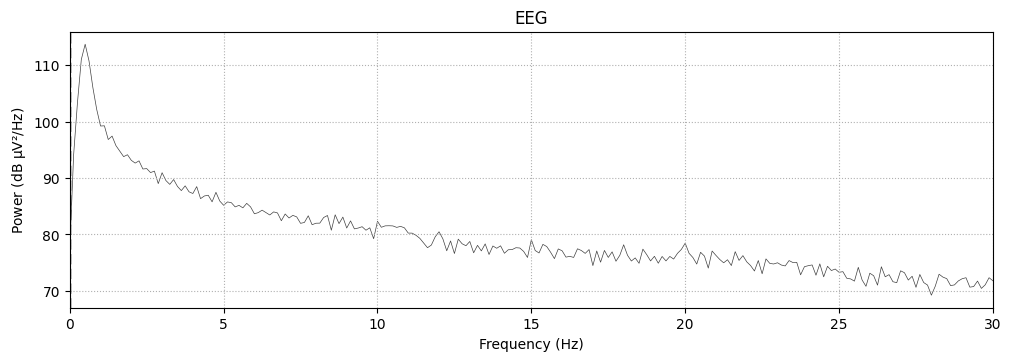

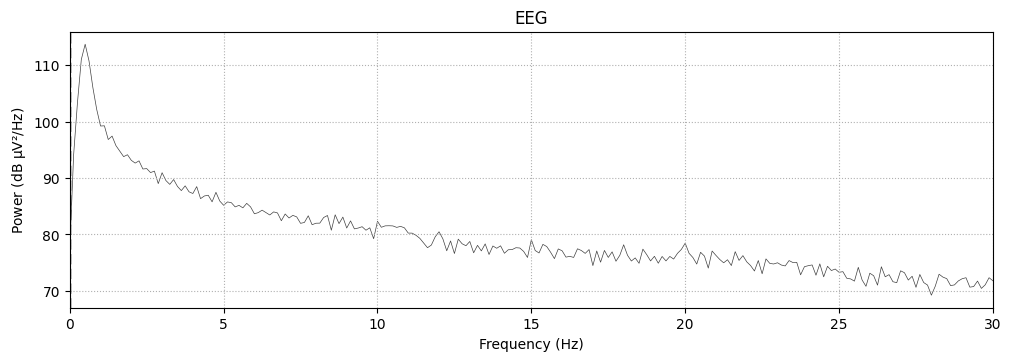

In [159]:
ica_sources = ica.get_sources(raw).get_data()
info = mne.create_info(ch_names=ica.get_sources(raw).ch_names,
                       sfreq=raw.info['sfreq'],
                       ch_types='eeg')

ica_raw = mne.io.RawArray(ica_sources, info)

psd = ica_raw.compute_psd(fmax=30)
psd.plot(picks='ICA000') 

Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/b_/13ns3vn128sfcpkm5ql4glyw0000gn/T/ipykernel_19446/1299752186.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot(picks='ICA001')
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


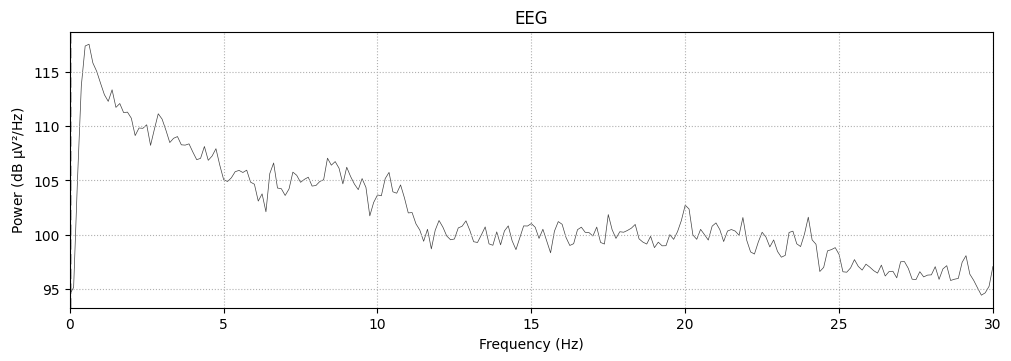

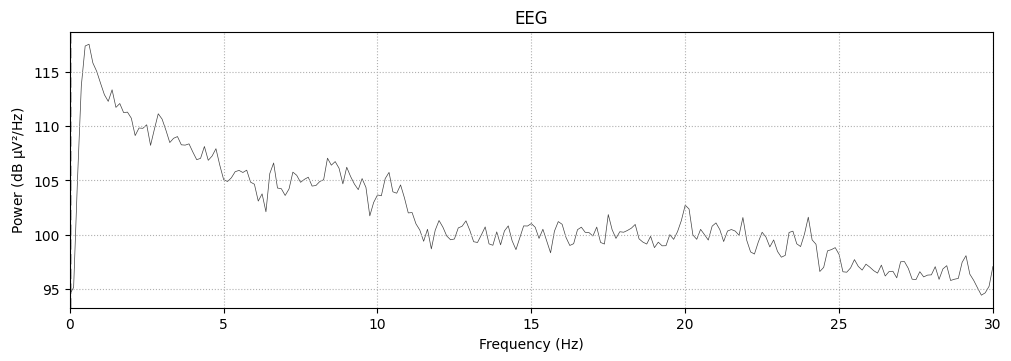

In [142]:
psd.plot(picks='ICA001') 

Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/b_/13ns3vn128sfcpkm5ql4glyw0000gn/T/ipykernel_19446/638011525.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot(picks='ICA002')
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


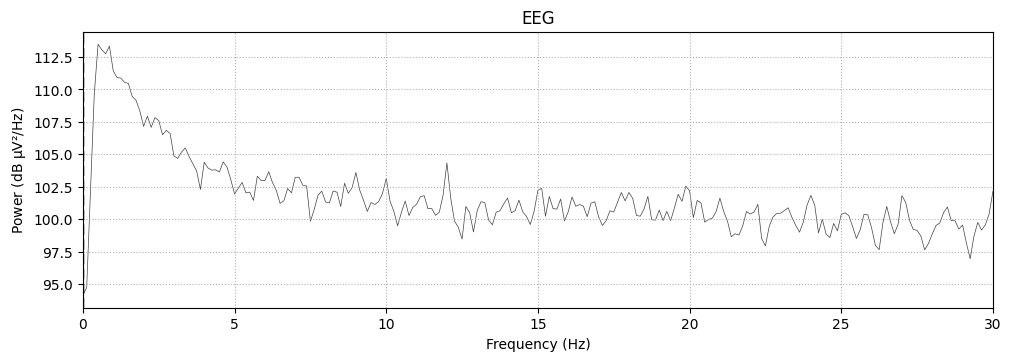

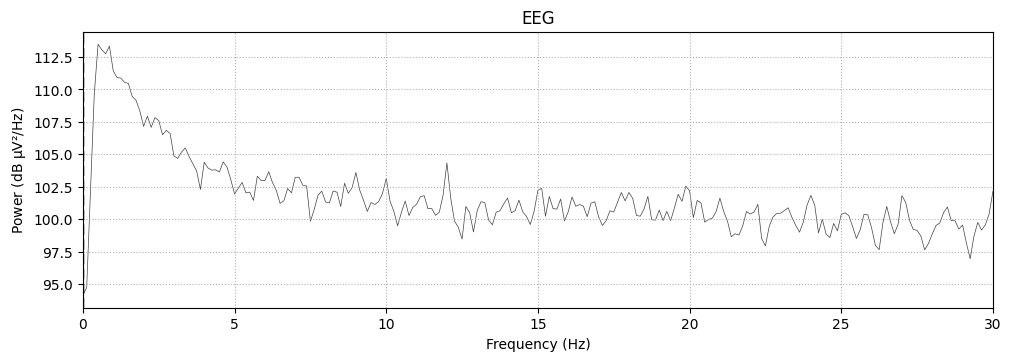

In [138]:
psd.plot(picks='ICA002') 

Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/b_/13ns3vn128sfcpkm5ql4glyw0000gn/T/ipykernel_19446/615359474.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot(picks='ICA003')
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


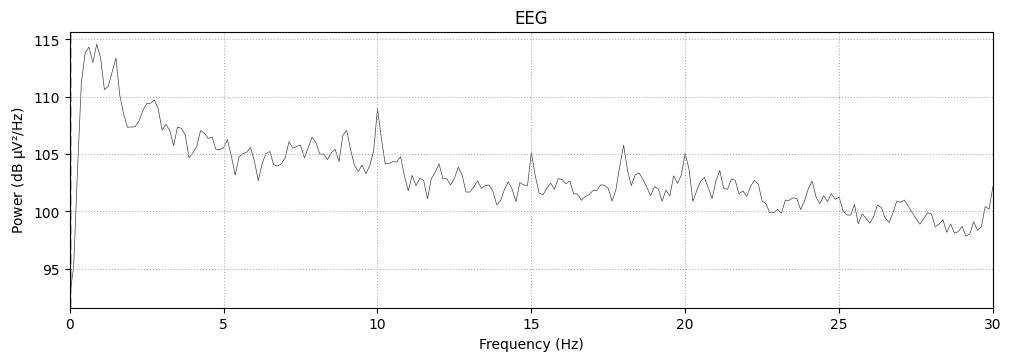

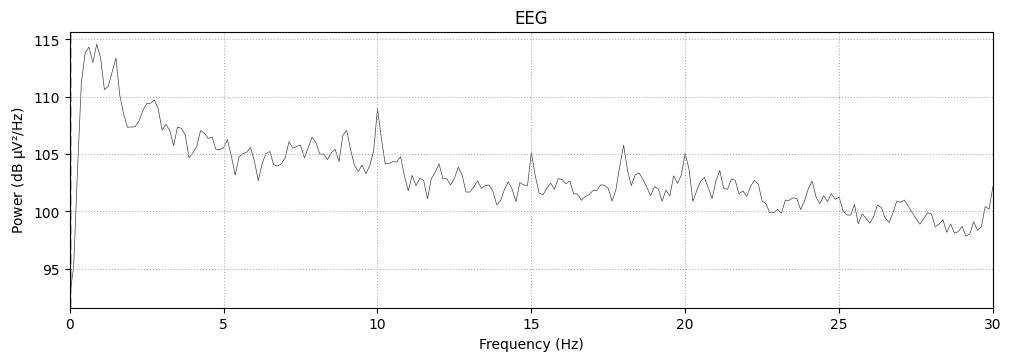

In [139]:
psd.plot(picks='ICA003') 

Plotting power spectral density (dB=True).
Need more than one channel to make topography for eeg. Disabling interactivity.


/var/folders/b_/13ns3vn128sfcpkm5ql4glyw0000gn/T/ipykernel_19446/313017255.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot(picks='ICA004')
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/mne/viz/utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


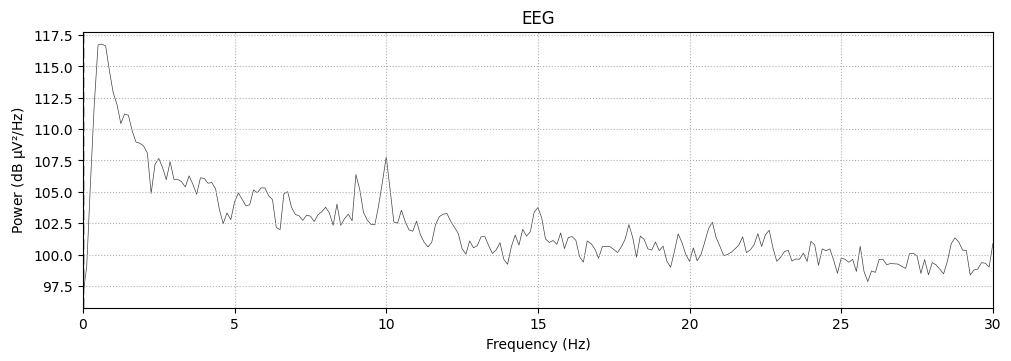

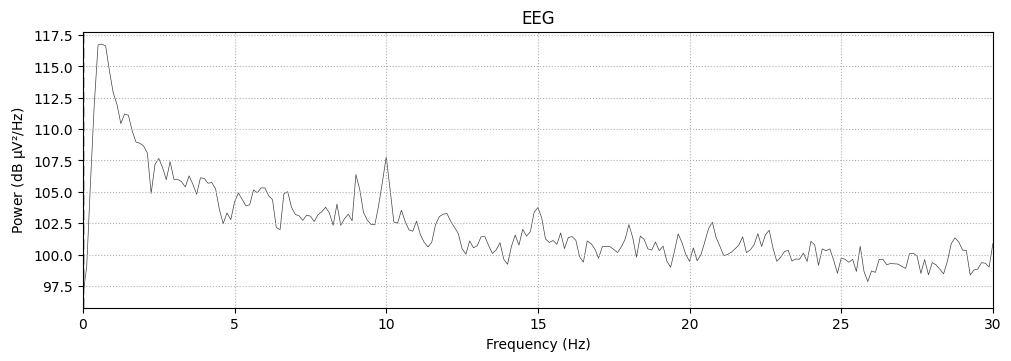

In [140]:
psd.plot(picks='ICA004') 

In [175]:
ica.exclude = [0, 1, 2, 3]
raw_clean = raw.copy()
ica.apply(raw_clean)        # no ICA000 and ICA001 
raw_clean.filter(7., 18., fir_design='firwin')


Applying ICA to Raw instance
    Transforming to ICA space (5 components)
    Zeroing out 4 ICA components
    Projecting back using 8 PCA components
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 18 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 18.00 Hz
- Upper transition bandwidth: 4.50 Hz (-6 dB cutoff frequency: 20.25 Hz)
- Filter length: 423 samples (1.652 s)



<RawArray | 8 x 57728 (225.5 s), ~3.5 MiB, data loaded>

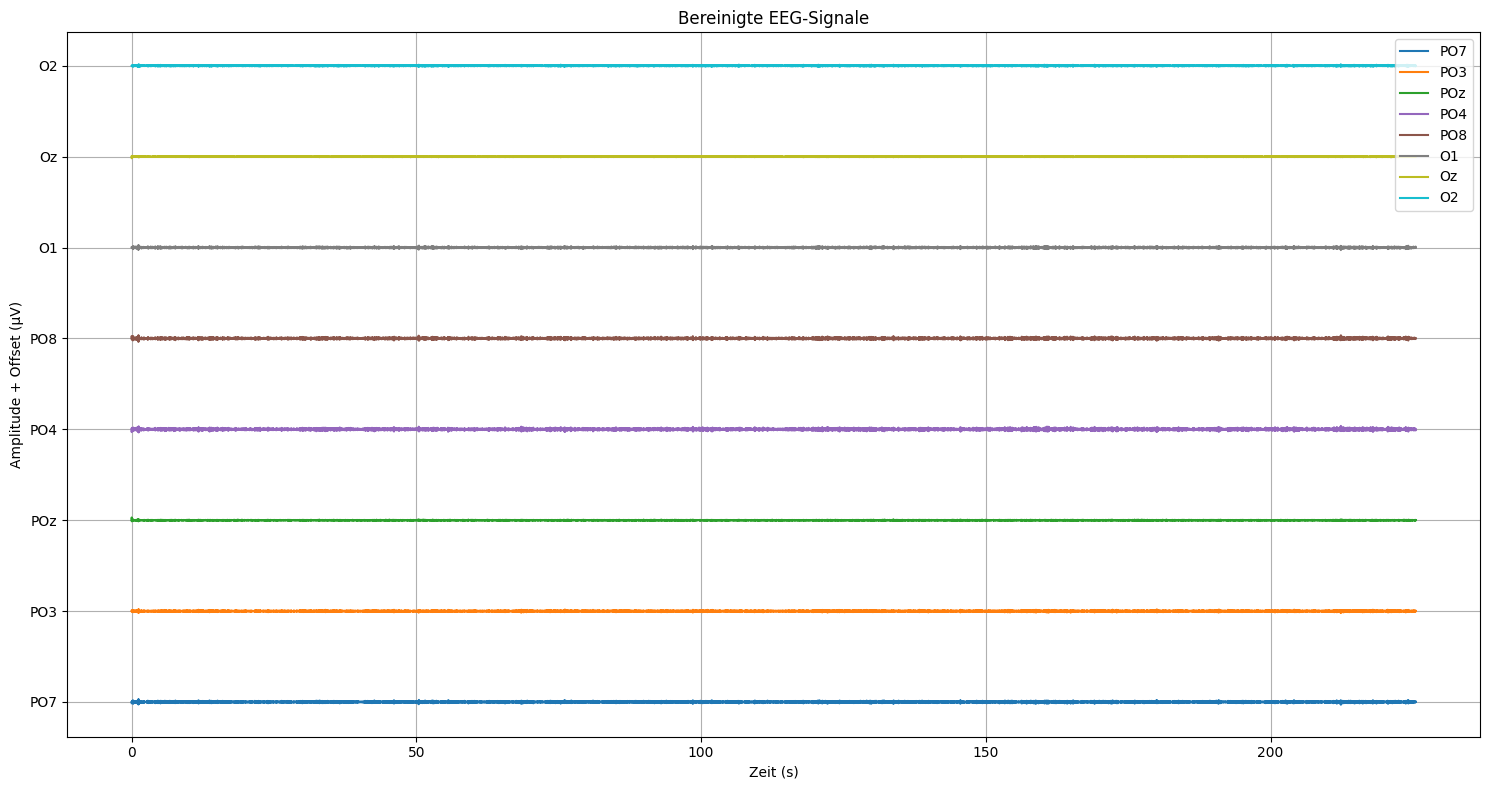

In [176]:
import matplotlib.pyplot as plt
import numpy as np


data, times = raw_clean.get_data(return_times=True)  # raw_clean = ICA-bereinigte Daten
ch_names = raw_clean.ch_names
sfreq = raw_clean.info['sfreq']  # Abtastrate

start_sec = 0
duration_sec = 250
start_sample = int(start_sec * sfreq)
end_sample = int((start_sec + duration_sec) * sfreq)

data = data[:, start_sample:end_sample]
times = times[start_sample:end_sample]

# Plotten
plt.figure(figsize=(15, 8))
offset = 300  # disctance between channnels
colors = plt.cm.tab10(np.linspace(0, 1, len(data)))  # colors

for i, (ch_data, name) in enumerate(zip(data, ch_names)):
    plt.plot(times, ch_data + i * offset, color=colors[i], label=name)

plt.xlabel("Zeit (s)")
plt.ylabel("Amplitude + Offset (µV)")
plt.title("Bereinigte EEG-Signale")
plt.yticks([i * offset for i in range(len(ch_names))], ch_names)
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
raw_clean.plot_psd(fmax=30)
raw_clean.plot_psd(
    fmin=7,        
    fmax=18,      
    average=True,  
    picks='eeg',  
    dB=True         # log
)

Effective window size : 8.000 (s)


ModuleNotFoundError: No module named 'pandas'